In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [103]:
pd.set_option('display.max_columns',None)

In [104]:
df=pd.read_csv("bank_churn.csv")

In [105]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [106]:
df.shape

(10000, 14)

In [107]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [109]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [110]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [111]:
df.duplicated().sum()

np.int64(0)

In [112]:
df_new=df.drop(columns=['RowNumber','CustomerId','Surname'])

In [113]:
cat_cols = df_new.select_dtypes(include='object').columns
num_cols = df_new.select_dtypes(exclude='object').columns

print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

Categorical Columns:
Index(['Geography', 'Gender'], dtype='object')

Numerical Columns:
Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [114]:
df_new['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [115]:
df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

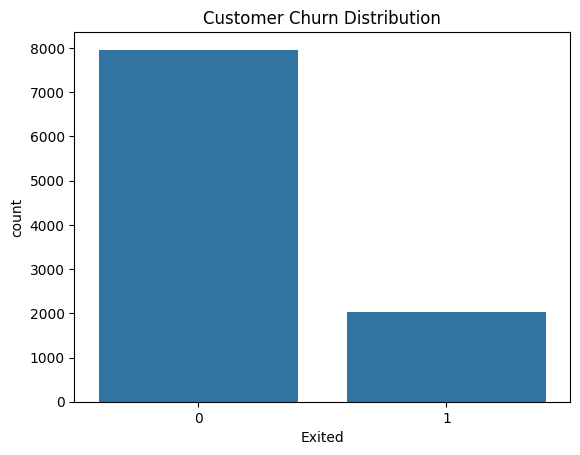

In [116]:
sns.countplot(x='Exited', data=df_new)
plt.title("Customer Churn Distribution")
plt.show()

In [117]:
df_new[num_cols].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [118]:
pd.crosstab(df_new['Geography'], df_new['Exited'])

Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


In [119]:
pd.crosstab(df_new['Geography'], df_new['Exited'], normalize='index') * 100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


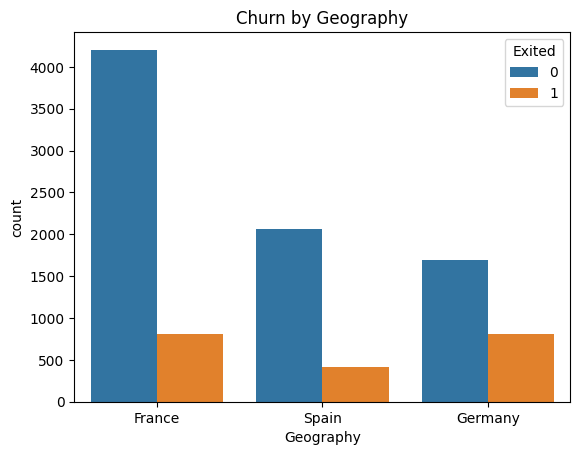

In [120]:
sns.countplot(x='Geography', hue='Exited', data=df_new)
plt.title("Churn by Geography")
plt.show()

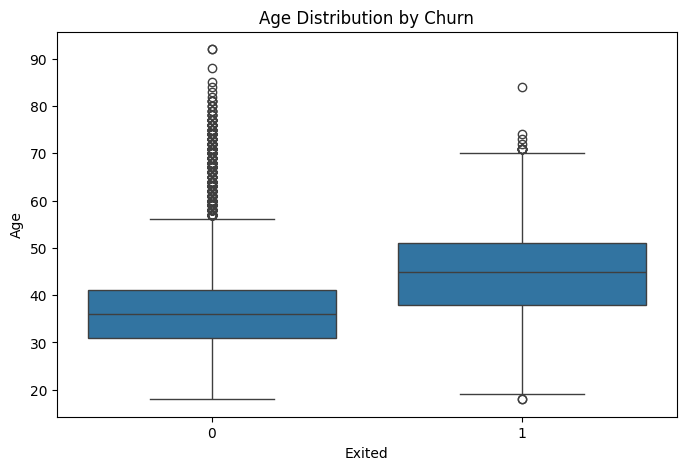

In [121]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Age', data=df_new)
plt.title("Age Distribution by Churn")
plt.show()

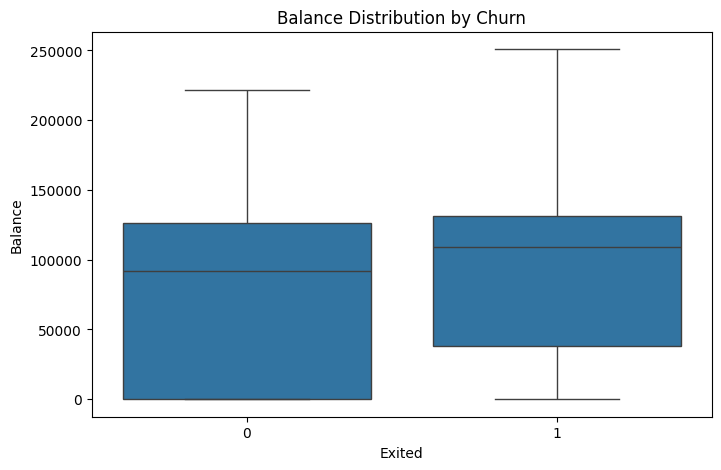

In [122]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Balance', data=df_new)
plt.title("Balance Distribution by Churn")
plt.show()

In [123]:
pd.crosstab(df_new['IsActiveMember'], df_new['Exited'], normalize='index') * 100

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


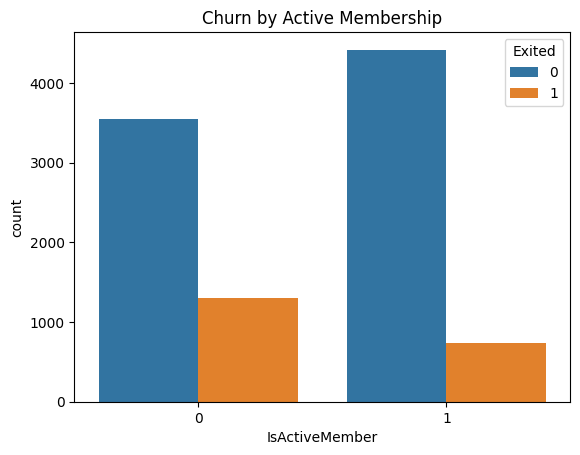

In [124]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df_new)
plt.title("Churn by Active Membership")
plt.show()

In [125]:
pd.crosstab(df_new['NumOfProducts'], df_new['Exited'], normalize='index') * 100

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


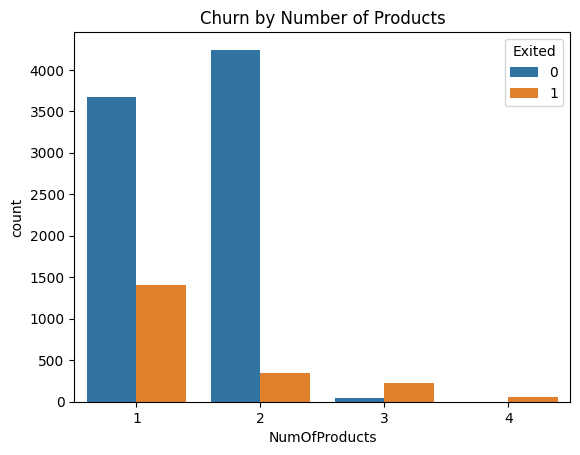

In [126]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df_new)
plt.title("Churn by Number of Products")
plt.show()

In [127]:
corr = df_new.corr(numeric_only=True)
corr

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


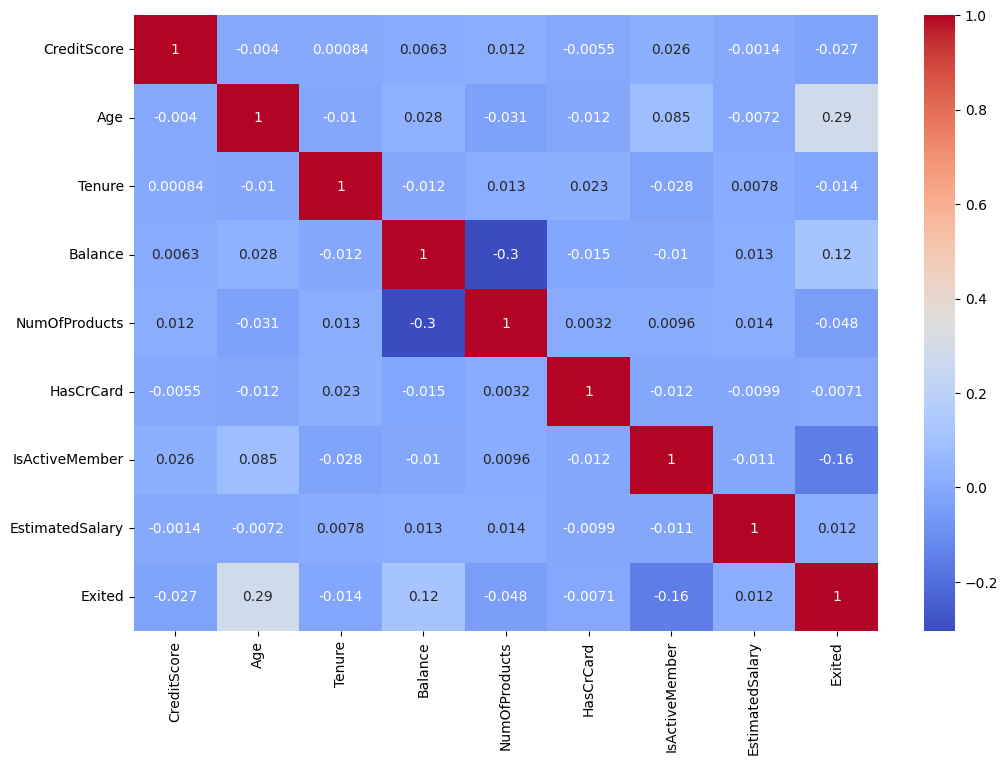

In [128]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [129]:
df_new['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [130]:
pd.crosstab(df_new['NumOfProducts'], df_new['Exited'], normalize='index') * 100

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


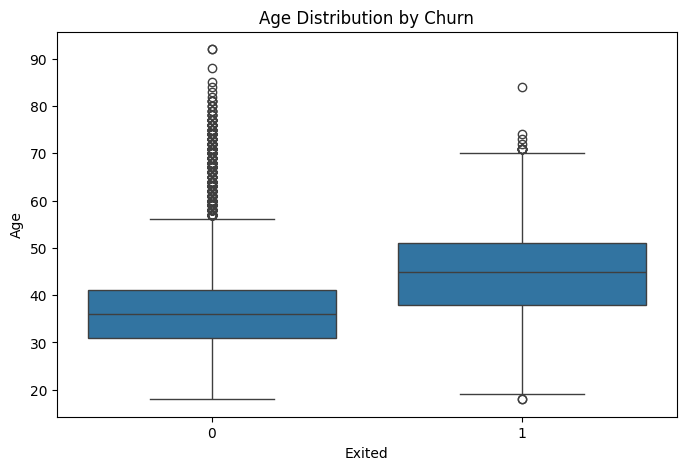

In [131]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Age', data=df_new)
plt.title("Age Distribution by Churn")
plt.show()

In [132]:
df_new.groupby('Exited')['Age'].mean()

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

In [133]:
pd.crosstab(
    [df_new['Geography'], df_new['IsActiveMember']],
    df_new['Exited'],
    normalize='index'
) * 100

Exited                            0          1
Geography IsActiveMember                      
France    0               78.869170  21.130830
          1               88.498649  11.501351
Germany   0               58.921491  41.078509
          1               76.282051  23.717949
Spain     0               76.652361  23.347639
          1               89.253049  10.746951

In [134]:
pd.crosstab(df_new['Gender'], df_new['Exited'], normalize='index') * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


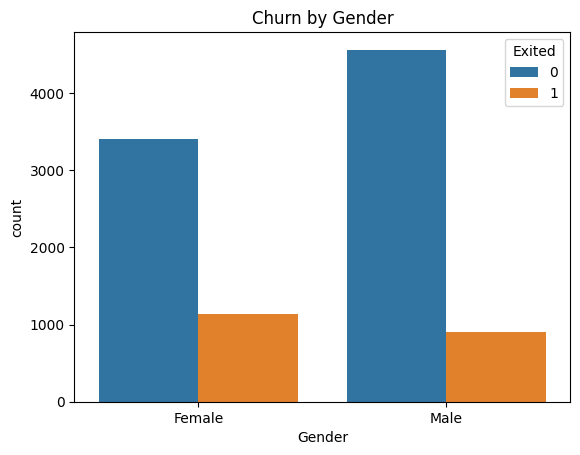

In [135]:
sns.countplot(x='Gender', hue='Exited', data=df_new)
plt.title("Churn by Gender")
plt.show()

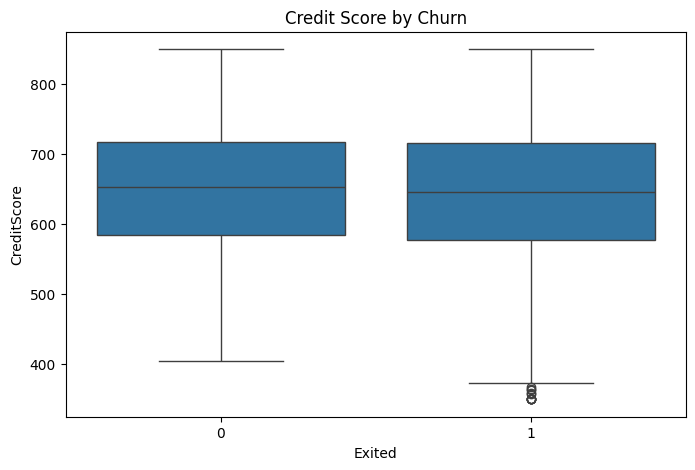

In [136]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='CreditScore', data=df_new)
plt.title("Credit Score by Churn")
plt.show()

In [137]:
df_new.groupby('Exited')['CreditScore'].mean()

Exited
0    651.853196
1    645.351497
Name: CreditScore, dtype: float64

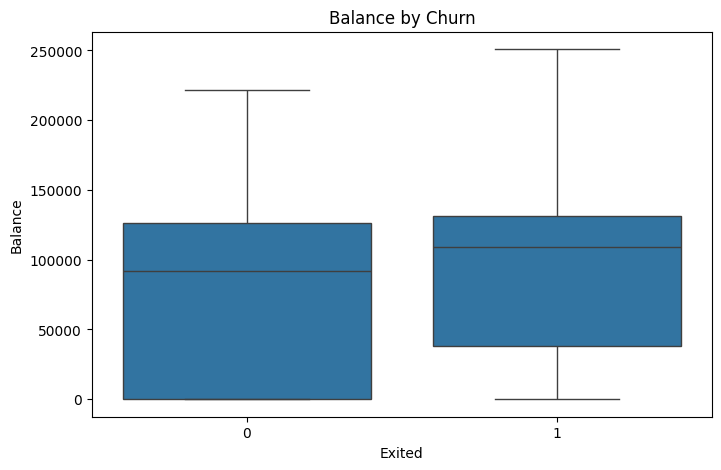

In [138]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Balance', data=df_new)
plt.title("Balance by Churn")
plt.show()

In [139]:
df_new.groupby('Exited')['Balance'].mean()

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

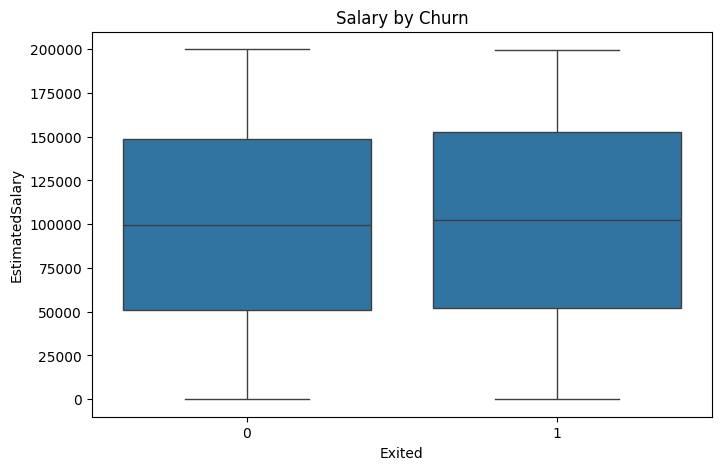

In [140]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='EstimatedSalary', data=df_new)
plt.title("Salary by Churn")
plt.show()

In [141]:
df_new.groupby('Exited')['EstimatedSalary'].mean()

Exited
0     99738.391772
1    101465.677531
Name: EstimatedSalary, dtype: float64

In [142]:
df_new.groupby('Exited')['Tenure'].mean()

Exited
0    5.033279
1    4.932744
Name: Tenure, dtype: float64

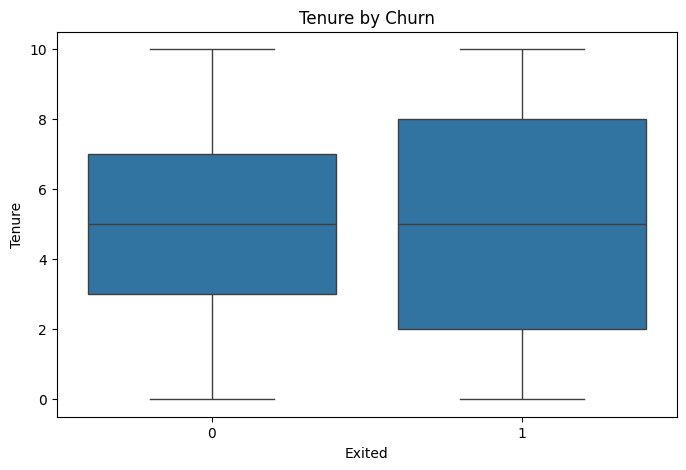

In [143]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Tenure', data=df_new)
plt.title("Tenure by Churn")
plt.show()

In [144]:
pd.crosstab(df_new['HasCrCard'], df_new['Exited'], normalize='index') * 100

Exited,0,1
HasCrCard,,
0,79.185059,20.814941
1,79.815734,20.184266


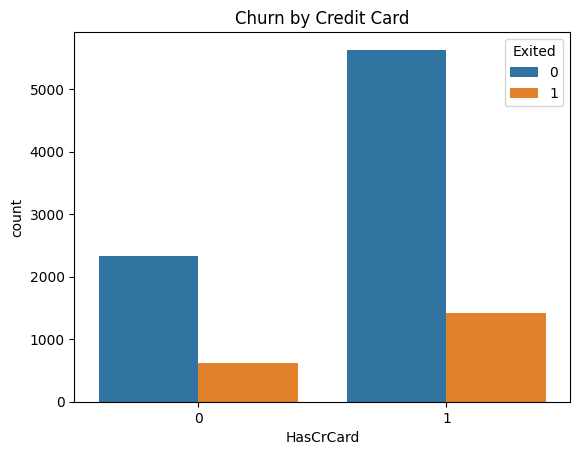

In [145]:
sns.countplot(x='HasCrCard', hue='Exited', data=df_new)
plt.title("Churn by Credit Card")
plt.show()

In [146]:
df_new['AgeGroup'] = pd.cut(
    df_new['Age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+'],
    include_lowest=True
)

In [147]:
pd.crosstab(df_new['AgeGroup'], df_new['Exited'], normalize='index') * 100

Exited,0,1
AgeGroup,,
18-30,92.479675,7.520325
31-40,87.912829,12.087171
41-50,66.034483,33.965517
51-60,43.789210,56.210790
60+,75.215517,24.784483


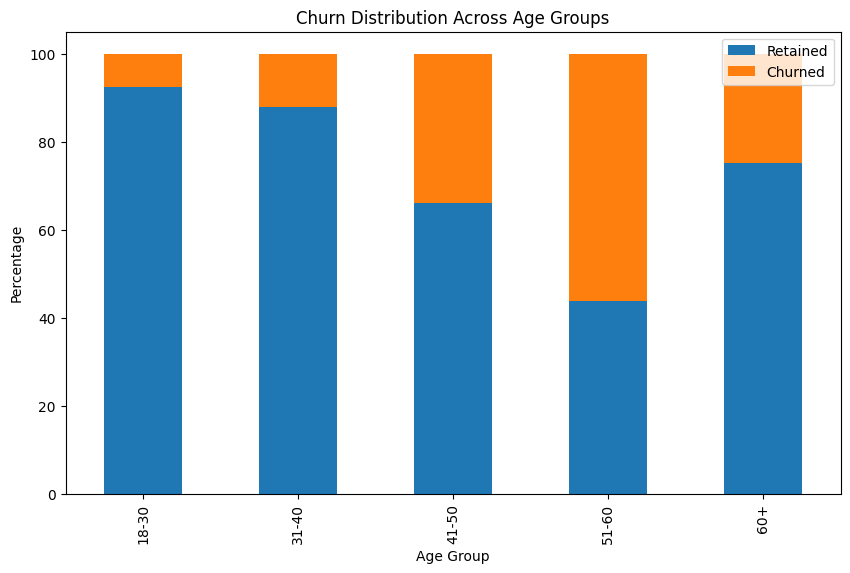

In [148]:
age_churn = pd.crosstab(
    df_new['AgeGroup'],
    df_new['Exited'],
    normalize='index'
) * 100

age_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Churn Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.legend(['Retained', 'Churned'])
plt.show()

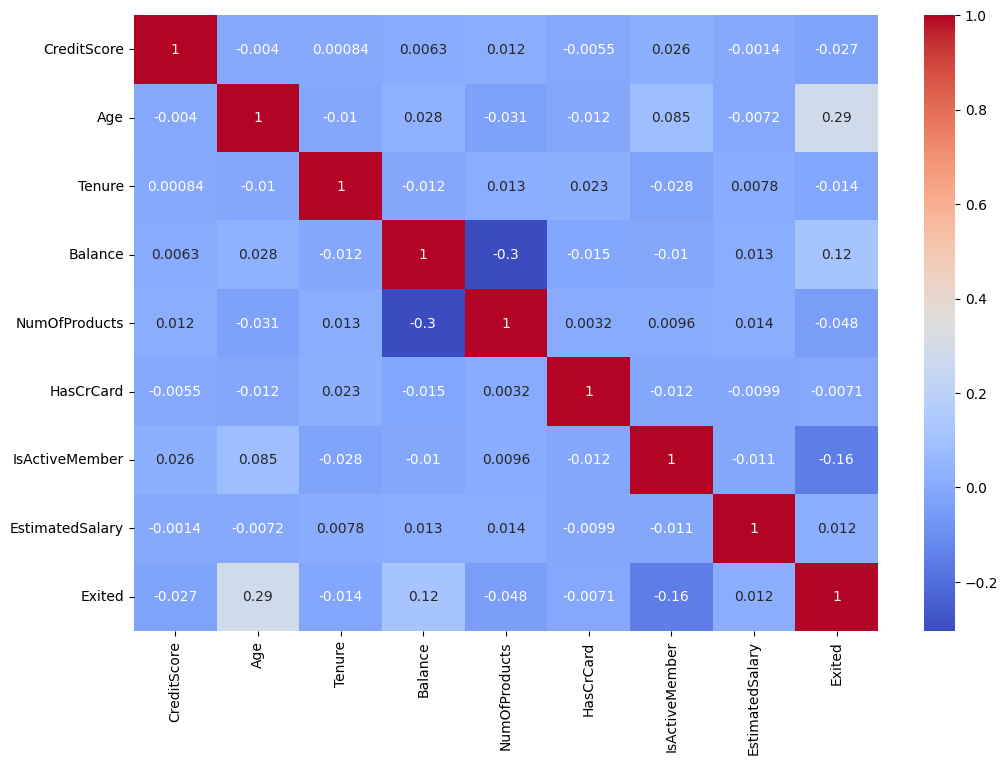

In [149]:
plt.figure(figsize=(12,8))
sns.heatmap(df_new.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [150]:
X = df_new.drop('Exited', axis=1)
y = df_new['Exited']

In [151]:
X = X.drop('AgeGroup', axis=1)

In [152]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [153]:
import sklearn
from sklearn.model_selection import train_test_split

In [154]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [155]:
from sklearn.preprocessing import StandardScaler

In [156]:
scaler = StandardScaler()

In [157]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [158]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000,)
(2000,)


In [159]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [160]:
y_pred = lr_model.predict(X_test_scaled)

In [161]:
y_prob = lr_model.predict_proba(X_test_scaled)[:,1]

In [162]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [163]:
accuracy_score(y_test, y_pred)

0.808

In [164]:
precision_score(y_test, y_pred)

0.5891472868217055

In [165]:
recall_score(y_test, y_pred)

0.18673218673218672

In [166]:
f1_score(y_test, y_pred)

0.2835820895522388

In [167]:
roc_auc_score(y_test, y_prob)

0.7747778595236223

In [168]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



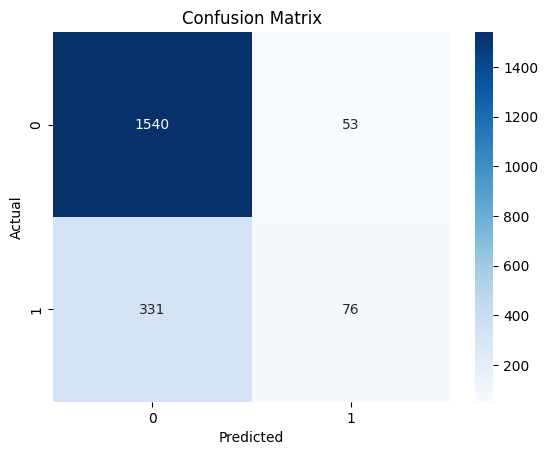

In [169]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [170]:
lr_balanced = LogisticRegression(class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [171]:
y_pred_bal = lr_balanced.predict(X_test_scaled)
y_prob_bal = lr_balanced.predict_proba(X_test_scaled)[:,1]

In [172]:
accuracy_score(y_test, y_pred_bal)

0.7135

In [173]:
precision_score(y_test, y_pred_bal)

0.38722826086956524

In [174]:
recall_score(y_test, y_pred_bal)

0.7002457002457002

In [175]:
f1_score(y_test, y_pred_bal)

0.49868766404199477

In [176]:
roc_auc_score(y_test, y_prob_bal)

0.7771376923919298

In [177]:
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [178]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    random_state=42
)

In [179]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [180]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [181]:
accuracy_score(y_test, y_pred_rf)

0.8645

In [182]:
precision_score(y_test, y_pred_rf)

0.7833333333333333

In [183]:
recall_score(y_test, y_pred_rf)

0.4619164619164619

In [184]:
f1_score(y_test, y_pred_rf)

0.5811437403400309

In [185]:
roc_auc_score(y_test, y_prob_rf)

0.852629208561412

In [186]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



In [187]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

In [188]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [189]:
feature_importance.head(10)

,Feature,Importance
1,Age,0.236485
7,EstimatedSalary,0.147016
0,CreditScore,0.142756
3,Balance,0.141756
4,NumOfProducts,0.130410
2,Tenure,0.081817
6,IsActiveMember,0.039933
8,Geography_Germany,0.028923
5,HasCrCard,0.018799
10,Gender_Male,0.018483


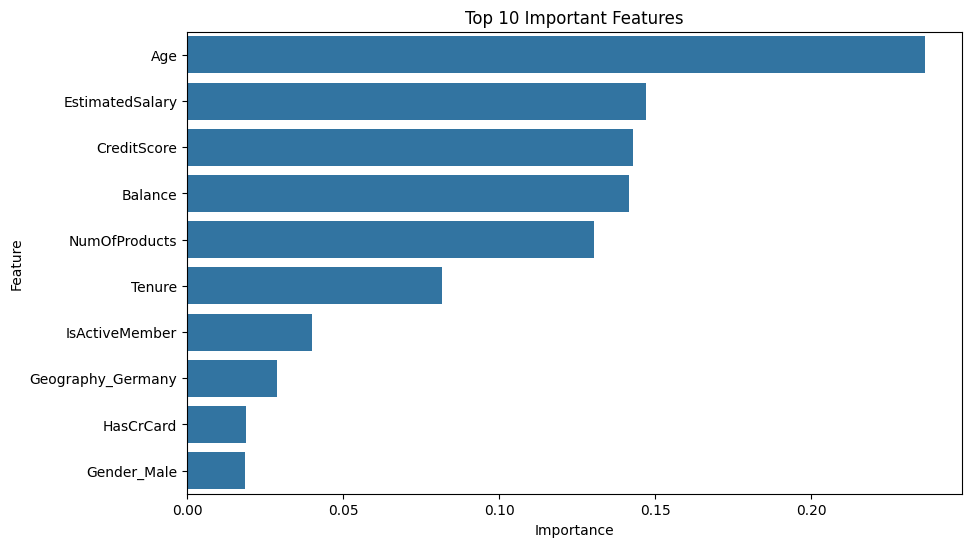

In [190]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

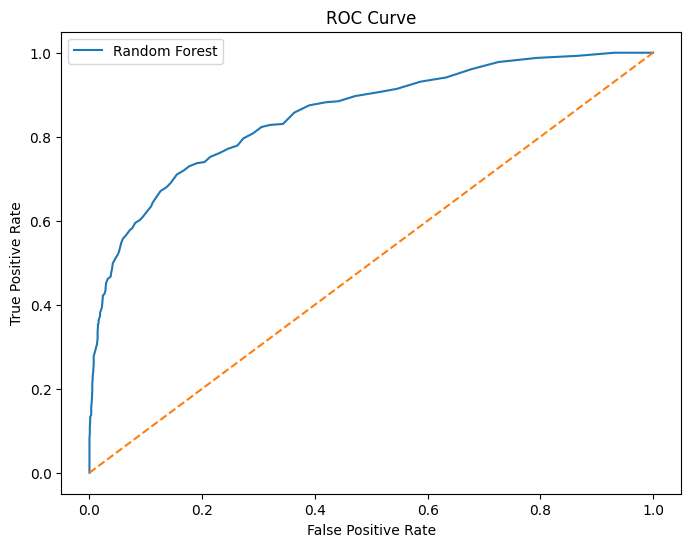

In [191]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [192]:
y_pred_thresh = (y_prob_rf >= 0.4).astype(int)
accuracy_score(y_test, y_pred_thresh)
precision_score(y_test, y_pred_thresh)
recall_score(y_test, y_pred_thresh)
f1_score(y_test, y_pred_thresh)
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1593
           1       0.67      0.58      0.62       407

    accuracy                           0.86      2000
   macro avg       0.78      0.75      0.77      2000
weighted avg       0.85      0.86      0.85      2000



In [193]:
y_pred_thresh = (y_prob_rf >= 0.6).astype(int)
accuracy_score(y_test, y_pred_thresh)
precision_score(y_test, y_pred_thresh)
recall_score(y_test, y_pred_thresh)
f1_score(y_test, y_pred_thresh)
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1593
           1       0.84      0.37      0.52       407

    accuracy                           0.86      2000
   macro avg       0.85      0.68      0.72      2000
weighted avg       0.85      0.86      0.83      2000



In [194]:
y_pred_thresh = (y_prob_rf >= 0.45).astype(int)
accuracy_score(y_test, y_pred_thresh)
precision_score(y_test, y_pred_thresh)
recall_score(y_test, y_pred_thresh)
f1_score(y_test, y_pred_thresh)
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1593
           1       0.72      0.52      0.61       407

    accuracy                           0.86      2000
   macro avg       0.80      0.74      0.76      2000
weighted avg       0.85      0.86      0.85      2000



In [195]:
y_pred_thresh = (y_prob_rf >= 0.3).astype(int)
accuracy_score(y_test, y_pred_thresh)
precision_score(y_test, y_pred_thresh)
recall_score(y_test, y_pred_thresh)
f1_score(y_test, y_pred_thresh)
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1593
           1       0.56      0.68      0.61       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.83      2000



In [196]:
y_pred_thresh = (y_prob_rf >= 0.5).astype(int)
accuracy_score(y_test, y_pred_thresh)
precision_score(y_test, y_pred_thresh)
recall_score(y_test, y_pred_thresh)
f1_score(y_test, y_pred_thresh)
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.76      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [197]:
import sys
print(sys.executable)
!{sys.executable} -m pip install xgboost

C:\Users\aashu\AppData\Local\Programs\Python\Python312\python.exe



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\aashu\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [198]:
from xgboost import XGBClassifier

In [199]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [200]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.849
Precision: 0.6829268292682927
Recall: 0.48157248157248156
F1: 0.5648414985590778
ROC-AUC: 0.8328343752072566
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.68      0.48      0.56       407

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000



In [201]:
df_new.to_csv("bank_churn_cleaned.csv", index=False)

In [202]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    
    print("Threshold:", t)
    print("Accuracy:", accuracy_score(y_test, y_pred_t))
    print("Precision:", precision_score(y_test, y_pred_t))
    print("Recall:", recall_score(y_test, y_pred_t))
    print("F1:", f1_score(y_test, y_pred_t))
    print("-" * 40)

Threshold: 0.3
Accuracy: 0.829
Precision: 0.5720620842572062
Recall: 0.6339066339066339
F1: 0.6013986013986014
----------------------------------------
Threshold: 0.35
Accuracy: 0.8345
Precision: 0.5964467005076142
Recall: 0.5773955773955773
F1: 0.5867665418227216
----------------------------------------
Threshold: 0.4
Accuracy: 0.836
Precision: 0.6125356125356125
Recall: 0.5282555282555282
F1: 0.5672823218997362
----------------------------------------
Threshold: 0.45
Accuracy: 0.84
Precision: 0.637223974763407
Recall: 0.4963144963144963
F1: 0.5580110497237569
----------------------------------------
Threshold: 0.5
Accuracy: 0.849
Precision: 0.6829268292682927
Recall: 0.48157248157248156
F1: 0.5648414985590778
----------------------------------------
